Q. Analytical Derivation

In [1]:
import numpy as np

# ---------- Given matrices (fill with your values) ----------
A = np.array([[1, 0], [0, 1]])        # State transition A_{k-1}
G = np.array([[1, 0], [0, 1]])        # Noise gain G_{k-1}
H = np.array([[1, 0]])                # Observation matrix H_k

Sigma_w = np.eye(2) * 0.1             # Process noise covariance Σ_p
Sigma_v = np.eye(1) * 0.1             # Measurement noise covariance Σ_m

# Previous posterior
m_prev = np.array([[0], [0]])         # m_{k-1}
P_prev = np.eye(2)                    # P_{k-1}


# ---------- 1. Prediction step ----------
def predict(A, G, m_prev, P_prev, Sigma_w):
    m_minus = A @ m_prev
    P_minus = A @ P_prev @ A.T + G @ Sigma_w @ G.T
    return m_minus, P_minus

m_minus, P_minus = predict(A, G, m_prev, P_prev, Sigma_w)

print("Predicted mean m_k^-:\n", m_minus)
print("Predicted covariance P_k^-:\n", P_minus)


# ---------- 2. Output distribution ----------
def output_distribution(H, m_minus, P_minus, Sigma_v):
    y_mean = H @ m_minus
    y_cov = H @ P_minus @ H.T + Sigma_v
    return y_mean, y_cov

y_mean, y_cov = output_distribution(H, m_minus, P_minus, Sigma_v)

print("\nOutput mean:\n", y_mean)
print("Output covariance:\n", y_cov)


# ---------- 3. Joint distribution [x_k; y_k] ----------
def joint_distribution(H, m_minus, P_minus, Sigma_v):
    mean_joint = np.vstack((m_minus, H @ m_minus))

    cov_xx = P_minus
    cov_xy = P_minus @ H.T
    cov_yx = H @ P_minus
    cov_yy = H @ P_minus @ H.T + Sigma_v

    cov_joint = np.block([
        [cov_xx, cov_xy],
        [cov_yx, cov_yy]
    ])

    return mean_joint, cov_joint

mean_joint, cov_joint = joint_distribution(H, m_minus, P_minus, Sigma_v)

print("\nJoint mean:\n", mean_joint)
print("Joint covariance:\n", cov_joint)


# ---------- 4. Update step ----------
def kalman_update(H, m_minus, P_minus, Sigma_v, y_obs):
    S = H @ P_minus @ H.T + Sigma_v               # Innovation covariance
    K = P_minus @ H.T @ np.linalg.inv(S)         # Kalman gain

    m_post = m_minus + K @ (y_obs - H @ m_minus)
    P_post = (np.eye(P_minus.shape[0]) - K @ H) @ P_minus

    return K, m_post, P_post


# Example observation
y_obs = np.array([[1]])

K, m_post, P_post = kalman_update(H, m_minus, P_minus, Sigma_v, y_obs)

print("\nKalman Gain:\n", K)
print("Updated mean m_k:\n", m_post)
print("Updated covariance P_k:\n", P_post)


# ---------- 5. Conditional expectation & variance ----------
# These are simply:
E_x_given_y = m_post
Var_x_given_y = P_post

print("\nE[x_k | y_k]:\n", E_x_given_y)
print("Var[x_k | y_k]:\n", Var_x_given_y)

Predicted mean m_k^-:
 [[0]
 [0]]
Predicted covariance P_k^-:
 [[1.1 0. ]
 [0.  1.1]]

Output mean:
 [[0]]
Output covariance:
 [[1.2]]

Joint mean:
 [[0]
 [0]
 [0]]
Joint covariance:
 [[1.1 0.  1.1]
 [0.  1.1 0. ]
 [1.1 0.  1.2]]

Kalman Gain:
 [[0.91666667]
 [0.        ]]
Updated mean m_k:
 [[0.91666667]
 [0.        ]]
Updated covariance P_k:
 [[0.09166667 0.        ]
 [0.         1.1       ]]

E[x_k | y_k]:
 [[0.91666667]
 [0.        ]]
Var[x_k | y_k]:
 [[0.09166667 0.        ]
 [0.         1.1       ]]


Q. 1-D Example

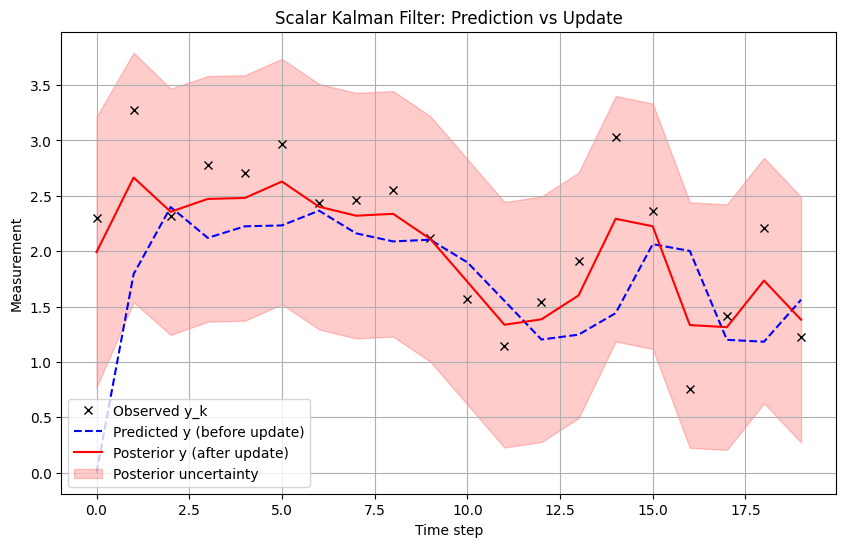

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Parameters ----------
a = 0.9     # state transition scalar
h = 1.2     # observation scalar
q = 0.1     # process noise variance
r = 0.2     # measurement noise variance

# Prior
m = 0.0     # m0
P = 1.0     # P0

# ---------- Store results ----------
m_list = []
P_list = []

y_pred_mean = []
y_pred_var = []

y_post_mean = []
y_post_var = []

# Generate synthetic observations
np.random.seed(0)
T = 20
x_true = np.zeros(T)
y_obs = np.zeros(T)

for k in range(T):
    # simulate system
    if k == 0:
        x_true[k] = np.random.normal(m, np.sqrt(P))
    else:
        x_true[k] = a * x_true[k-1] + np.random.normal(0, np.sqrt(q))

    y_obs[k] = h * x_true[k] + np.random.normal(0, np.sqrt(r))


# ---------- Kalman filter loop ----------
for k in range(T):

    # ----- 1. Prediction -----
    m_minus = a * m
    P_minus = a**2 * P + q

    # ----- 3. Predictive measurement distribution -----
    y_mean_pred = h * m_minus
    y_var_pred = h**2 * P_minus + r

    # Store
    y_pred_mean.append(y_mean_pred)
    y_pred_var.append(y_var_pred)

    # ----- 2. Update -----
    S = h**2 * P_minus + r
    K = (P_minus * h) / S

    m = m_minus + K * (y_obs[k] - h * m_minus)
    P = (1 - K * h) * P_minus

    # ----- 4. Posterior-predictive -----
    y_mean_post = h * m
    y_var_post = h**2 * P + r

    y_post_mean.append(y_mean_post)
    y_post_var.append(y_var_post)

    # Store state results
    m_list.append(m)
    P_list.append(P)


# ---------- 5. Visualization ----------
t = np.arange(T)

plt.figure(figsize=(10,6))

# Observations
plt.plot(t, y_obs, 'kx', label="Observed y_k")

# Predictive mean before update
plt.plot(t, y_pred_mean, 'b--', label="Predicted y (before update)")

# Posterior mean after update
plt.plot(t, y_post_mean, 'r-', label="Posterior y (after update)")

plt.fill_between(
    t,
    np.array(y_post_mean) - 2*np.sqrt(y_post_var),
    np.array(y_post_mean) + 2*np.sqrt(y_post_var),
    color='red', alpha=0.2, label="Posterior uncertainty"
)

plt.legend()
plt.title("Scalar Kalman Filter: Prediction vs Update")
plt.xlabel("Time step")
plt.ylabel("Measurement")
plt.grid()

plt.show()

Q. 2D-Position Estimation


Part A

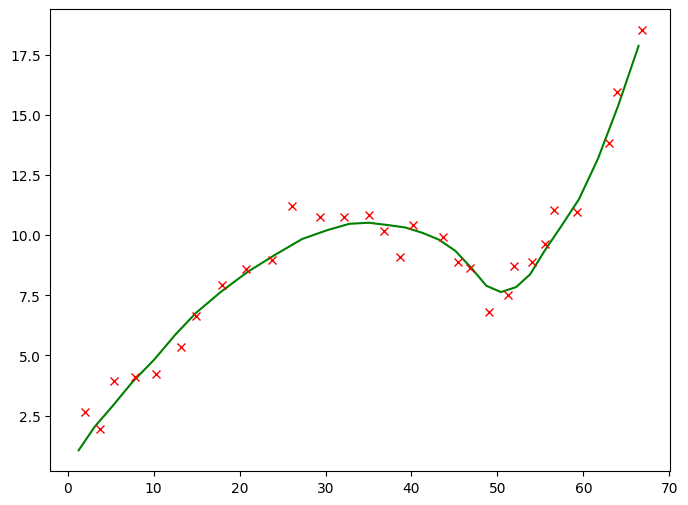

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Parameters ----------
dt = 1.0  # time step Δt

# ---------- Matrices (from your question) ----------
A = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

G = np.array([
    [0.5 * dt**2, 0],
    [0, 0.5 * dt**2],
    [dt, 0],
    [0, dt]
])

# ---------- Noise ----------
Sigma_p = np.eye(2) * 0.1  # process noise covariance
Sigma_m = np.eye(2) * 0.5  # measurement noise covariance

# Process noise mapped into state space
Q = G @ Sigma_p @ G.T

# ---------- Initial state ----------
x = np.array([[0], [0], [1], [1]])  # [px, py, vx, vy]
P = np.eye(4)

# ---------- Simulation ----------
np.random.seed(0)
T = 30

true_states = []
measurements = []
estimates = []

x_true = x.copy()

for k in range(T):
    # ----- True system -----
    w = np.random.multivariate_normal([0, 0], Sigma_p).reshape(-1, 1)
    x_true = A @ x_true + G @ w

    v = np.random.multivariate_normal([0, 0], Sigma_m).reshape(-1, 1)
    y = H @ x_true + v

    true_states.append(x_true[:2].flatten())
    measurements.append(y.flatten())

    # ----- Kalman Filter -----
    # 1. Prediction
    x_minus = A @ x
    P_minus = A @ P @ A.T + Q

    # 2. Update
    S = H @ P_minus @ H.T + Sigma_m
    K = P_minus @ H.T @ np.linalg.inv(S)

    x = x_minus + K @ (y - H @ x_minus)
    P = (np.eye(4) - K @ H) @ P_minus

    estimates.append(x[:2].flatten())

# Convert to arrays
true_states = np.array(true_states)
measurements = np.array(measurements)
estimates = np.array(estimates)

# ---------- Visualization ----------
plt.figure(figsize=(8, 6))

plt.plot(true_states[:, 0], true_states[:, 1], 'g-', label="True path")
plt.plot(measurements[:, 0], measurements[:, 1], 'rx', label="Measurements")


Part B

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class GPSKalmanFilter:
    def __init__(self, dt, process_var, meas_var):
        """
        dt: time step
        process_var: variance of acceleration noise
        meas_var: variance of GPS measurement noise
        """

        self.dt = dt

        # State vector: [px, py, vx, vy]
        self.x = np.zeros((4, 1))

        # State covariance
        self.P = np.eye(4) * 500

        # State transition matrix
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        # Measurement matrix (GPS gives position only)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process noise
        G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        self.Q = G @ np.eye(2) * process_var @ G.T

        # Measurement noise
        self.R = np.eye(2) * meas_var

    def predict(self):
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q

    def update(self, z):
        z = z.reshape(2, 1)

        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ (z - self.H @ self.x)
        self.P = (np.eye(4) - K @ self.H) @ self.P

        return self.x


# ---------- Example usage with noisy GPS ----------

np.random.seed(1)

dt = 1.0
kf = GPSKalmanFilter(dt, process_var=0.1, meas_var=5.0)

T = 50

true_path = []
gps_measurements = []
filtered_path = []

# Simulated true motion
